<a href="https://colab.research.google.com/github/ardhiansyahprimadikaadi/AI_Praktikum-1_09020624024/blob/main/AI_Praktikum_Linear_Berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum Analisis Code Regresi Linear Berganda**
## Dataset : Penjualan Mobil
### Nama : Ardhiansyah Primadika Adi
### Kelas : H6C
### NIM : 09020624024


---

### **Langkab 1 : Impor Library**
Tahap awal adalah memanggil semua modul yang diperlukan untuk pengolahan data, perhitungan numerik, pemodelan, dan visualisasi.
*  pandas: Digunakan untuk mengonversi data mentah menjadi struktur tabel (DataFrame).
*  numpy: Dibutuhkan untuk operasi matematika, seperti menghitung akar kuadrat pada metrik RMSE.
*  matplotlib: Digunakan untuk menyajikan hasil dalam bentuk grafik.
*  sklearn: Library utama untuk algoritma machine learning (Regresi) dan metrik evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

### **Langkah 2: Menyiapkan Dataset**
Dataset ini menghubungkan Tenaga Kuda, Efisiensi (MPG), dan Berat Mobil sebagai faktor yang memengaruhi Harga Jual mobil dalam satuan Juta Rupiah.

In [3]:
data_mobil = {
    'tenaga_mesin': [100, 150, 200, 250, 300, 350, 400, 450, 500, 550],
    'efisiensi_mpg': [35, 30, 28, 25, 22, 20, 18, 15, 12, 10],
    'berat_mobil': [1200, 1350, 1500, 1600, 1750, 1900, 2100, 2200, 2400, 2500],
    'harga_jual': [200, 300, 450, 600, 750, 950, 1200, 1500, 1850, 2200]
}
df_mobil = pd.DataFrame(data_mobil)
print(df_mobil)

   tenaga_mesin  efisiensi_mpg  berat_mobil  harga_jual
0           100             35         1200         200
1           150             30         1350         300
2           200             28         1500         450
3           250             25         1600         600
4           300             22         1750         750
5           350             20         1900         950
6           400             18         2100        1200
7           450             15         2200        1500
8           500             12         2400        1850
9           550             10         2500        2200


### Analisis
Data ini mencerminkan kondisi nyata di pasar otomotif. Terlihat pola bahwa mobil dengan tenaga besar biasanya harganya lebih mahal, namun bensinnya cenderung lebih boros. Model ini akan menghitung bagaimana ketiga hal tersebut digabungkan untuk menentukan harga sebuah mobil.


###**Langkah 3 : Menentukan Variabel X dan Y**
Menentukan mana faktor penyebab (X) yaitu tenanga mesin, efisiensi dan berat mobil dan mana hasil yang ingin ditebak (Y) yaitu harga jual.

In [4]:
X = df_mobil[['tenaga_mesin', 'efisiensi_mpg', 'berat_mobil']]
y = df_mobil['harga_jual']

### Analisis
Variabel X berisi tiga kolom sekaligus karena harga mobil tidak mungkin hanya ditentukan oleh satu hal saja. Di sini, performa mesin, keiritan, dan ukuran fisik mobil dianggap sebagai faktor utama yang menentukan nilai jual (Y).

### **Langkah 4: Pembagian Data**
Data dibagi menjadi dua bagian: 80% untuk model belajar (latihan) dan 20% untuk ujian (tes).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Analisis
Alasan pembagian ini adalah untuk memastikan model benar-benar paham dan tidak hanya sekadar menghafal data. Dengan memberikan 20% data untuk ujian, dapat diketahui apakah model tetap akurat saat menebak harga mobil yang belum pernah ia lihat sebelumnya.

###**Langkah 5: Inisialisasi dan Pelatihan Model**
Pada tahap ini, komputer mencari rumus matematika yang paling pas untuk menghubungkan tenaga, MPG, dan berat ke angka harga. Model berusaha agar selisih antara tebakannya dengan harga asli sekecil mungkin.

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### **Langkah 6: Menampilkan Parameter Regresi**
Mengeluarkan angka intercept ( a ) dan koefisien ( b1,b2,b3 ).
*   **Koefisien b1 (Tenaga Mesin)**: Menjelaskan berapa kenaikan harga untuk setiap tambahan 1 tenaga mesin.
*   **Koefisien b2 (Efisiensi MPG)**: Menjelaskan pengaruh keiritan bensin terhadap harga. Nilai negatif di sini sering kali menunjukkan bahwa mobil mewah/mahal justru memang lebih boros bensin.
*   **Koefisien b3 (Berat Mobil)**: Menjelaskan pengaruh berat/ukuran mobil terhadap harga.






In [7]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 = tenaga mesin
# b2 = efisiensi
# b3 = berat mobil

Intercept (a): -5632.908847184985
Koefisien (b1, b2, b3): [ 18.80160858 173.1233244   -1.75737265]


### Analisis Hasil
*  **Intercept (a = -5632.90) :** Angka ini adalah titik dasar secara matematika. Dalam praktiknya, angka negatif ini muncul untuk menyeimbangkan rumus agar garis prediksi tetap akurat mengikuti sebaran data mobil yang tersedia.
*  **Koefisien (b1 = 18.80) :** Setiap kenaikan 1 tenaga mesin, harga mobil diprediksi akan naik sebesar 18,80 Juta Rupiah. Ini menunjukkan bahwa performa mesin memiliki pengaruh positif yang cukup kuat terhadap harga jual.
*  **Koefisien (b2 = 173.12) :** Setiap kenaikan 1 unit keiritan (MPG), harga mobil diprediksi naik sangat drastis sebesar 173,12 Juta Rupiah. Hal ini menandakan bahwa dalam data ini, tingkat kehematan bahan bakar menjadi faktor paling mahal yang mendongkrak harga mobil.
*  **Koefisien (b3 = -1.75) :** Berbeda dengan lainnya, angka ini bernilai negatif. Artinya, setiap berat mobil bertambah 1 kg, harga justru diprediksi turun sekitar 1,75 Juta Rupiah. Ini bisa terjadi jika mobil yang lebih ringan (seperti mobil sport menggunakan bahan karbon) dianggap lebih berharga daripada mobil yang berat namun lambat.





### **Langkah 7: Prediksi Data Testing**
Menguji hasil prediksi model terhadap data pengujian, dimana langkah ini menunjukkan hasil kerja model dalam menggabungkan tiga spesifikasi sekaligus menjadi satu angka harga. Jika angka tebakan (prediksi) sangat mirip dengan harga asli (aktual), berarti model sudah berhasil memahami pola pasar otomotif tersebut.

In [8]:
y_pred = model.predict(X_test)
print("Harga Prediksi (Juta):", y_pred)
print("Harga Aktual (Juta):", y_test.values)

Harga Prediksi (Juta): [1627.68096515    8.57908847]
Harga Aktual (Juta): [1850  300]


### Analisis Hasil
#### Perbandingan Nilai Data Pertama:
*   Harga Aktual: 1850 Juta.
*   Harga Prediksi: 1627.68 Juta.
*   Terdapat selisih (error) sekitar 222 Juta Rupiah. Meskipun angka prediksi sudah berada pada rentang ribuan juta, perbedaan ini menunjukkan bahwa untuk mobil dengan spesifikasi harga tinggi, model masih memiliki margin kesalahan yang cukup lebar.
#### Perbandingan Nilai Data Kedua:
*   Harga Aktual: 300 Juta.
*   Harga Prediksi: 8.57 Juta.
*   Terjadi penyimpangan yang sangat signifikan pada data kedua, di mana model menebak angka yang jauh lebih rendah (hanya 8,57 juta) dibandingkan harga aslinya. Hal ini mengindikasikan adanya ketidakseimbangan antara variabel berat mobil yang bernilai negatif dengan variabel tenaga dan MPG pada titik data tersebut.






### **Langkah 8: Evaluasi Metrik (MAE, MSE, RMSE)**
Menghitung selisih kesalahan antara hasil prediksi model dengan data asli di lapangan untuk mengukur tingkat keakuratan.

In [9]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 256.8699731903507
MSE: 67175.95046683429
RMSE: 259.1832372412118


### Analisis Hasil
#### *MAE : 256.86*
Secara rata-rata, prediksi harga mobil meleset sekitar 256,86 Juta Rupiah dari harga aslinya. Angka ini memberikan gambaran kesalahan rata-rata dalam satuan yang mudah dipahami (juta rupiah) tanpa mempertimbangkan arah kesalahan (apakah prediksi terlalu tinggi atau terlalu rendah).
#### *MSE : 67175.95*
Nilai ini merupakan rata-rata dari kuadrat kesalahan prediksi. Karena nilainya sangat besar (mencapai angka 67 ribu), hal ini mengindikasikan bahwa terdapat kesalahan prediksi yang sangat mencolok (outlier) pada setidaknya satu data pengujian. MSE sangat sensitif terhadap selisih angka yang besar karena setiap kesalahan dikuadratkan.
#### *RMSE : 259.18*
Hasil dari MSE ini menunjukkan bahwa standar deviasi dari kesalahan prediksi adalah 259,18 Juta Rupiah. Dibandingkan dengan rata-rata harga mobil dalam dataset (yang berkisar antara 200 hingga 2200 Juta), kesalahan sebesar ~259 Juta tergolong cukup signifikan (sekitar 11-12% dari rentang harga maksimal).



### **Langkah 9: Prediksi Data Baru**
Menebak harga mobil baru dengan spesifikasi: Tenaga 320 HP, MPG 21, dan Berat 1800 kg.


In [10]:
data_baru = pd.DataFrame({'tenaga_mesin': [320], 'efisiensi_mpg': [21], 'berat_mobil': [1800]})
prediksi_baru = model.predict(data_baru)
print("Prediksi harga jual mobil baru:", prediksi_baru[0], "juta rupiah")

Prediksi harga jual mobil baru: 855.9249329758695 juta rupiah


### Analisis Hasil
Angka 855,92 juta ini didapatkan dari penggabungan ketiga spesifikasi tersebut berdasarkan informasi yang sudah diambil model pada langkah-langkah sebelumnya. Model menambahkan pengaruh besar dari tenaga mesin dan efisiensi, lalu menguranginya sedikit karena faktor berat mobil.

### **Langkah 10: Visualisasi Grafik**
Menampilkan grafik untuk melihat seberapa pas tebakan model terhadap harga aslinya.

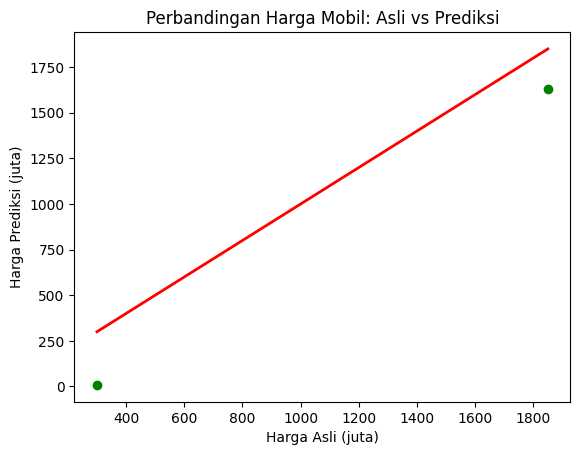

In [12]:
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Harga Asli (juta)")
plt.ylabel("Harga Prediksi (juta)")
plt.title("Perbandingan Harga Mobil: Asli vs Prediksi")
plt.show()

### Analisis Hasil
Grafik scatterplot menunjukkan bahwa model regresi berganda telah berhasil menangkap tren kenaikan harga, namun tingkat akurasinya belum maksimal. Posisi titik-titik hijau yang berada di bawah garis merah ideal menandakan bahwa model cenderung memberikan prediksi yang lebih murah (underestimate) dibandingkan harga aslinya. Jarak antara titik dan garis tersebut memvalidasi adanya kesalahan (error) yang menunjukkan bahwa model masih memerlukan lebih banyak data latihan agar hasil prediksinya bisa lebih presisi.

### **Kesimpulan**
Implementasi regresi linear berganda pada dataset penjualan mobil menunjukkan bahwa harga kendaraan dipengaruhi secara simultan oleh tenaga mesin, efisiensi bahan bakar (MPG), dan berat mobil, dengan efisiensi bahan bakar sebagai faktor penentu terkuat berdasarkan nilai koefisien yang dihasilkan. Meskipun model berhasil menjalankan fungsi estimasi otomatis untuk data baru, hasil evaluasi melalui metrik RMSE dan visualisasi scatterplot mengindikasikan adanya margin kesalahan yang cukup signifikan. Hal ini terlihat dari posisi titik data yang cenderung berada di bawah garis ideal (underestimate), sehingga model ini memerlukan lebih banyak variasi data latihan untuk meningkatkan presisi dan akurasi prediksinya.